# Along-track velocity validation

Sampling CMEMS effective currents (Eulerian + Stokes drift) along observed
drifter trajectories and comparing model-predicted velocity against observed
drifter velocity at each timestep. No Parcels, no forward simulation -- just
field interpolation and comparison.

This evaluates whether the velocity fields are compatible with the observed
drifter motion before running any trajectory simulations.

## Imports

In [1]:
import copernicusmarine as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

In [2]:
CSV_PATH = "examples/baltic_drifters/data/drifters_clean.csv"
TIME_START = "2023-04-24"
TIME_END = "2023-05-10"
K_B = 12    # buoy drag coefficient [kg/m]
K_D = 154   # drogue drag coefficient [kg/m]
RESAMPLE_INTERVAL = "1h"
EXAMPLE_DRIFTER = 298

## Load observed trajectories

Read clean drifter CSV and subsample to hourly fixes to match CMEMS
temporal resolution. Compute observed velocity from finite differences.

In [3]:
df = pd.read_csv(CSV_PATH, parse_dates=["date_UTC"])

# Subsample to hourly: for each drifter, resample by taking the nearest fix
records = []
for drifter_id, grp in df.groupby("D_number"):
    grp = grp.set_index("date_UTC").sort_index()
    grp_h = grp.resample(RESAMPLE_INTERVAL).first().dropna(subset=["Latitude"])
    grp_h["D_number"] = drifter_id
    records.append(grp_h.reset_index())

df_h = pd.concat(records, ignore_index=True)

# Compute observed velocity per drifter
obs_records = []
for drifter_id, grp in df_h.groupby("D_number"):
    grp = grp.sort_values("date_UTC").reset_index(drop=True)
    dt = grp["date_UTC"].diff().dt.total_seconds()
    dlat = grp["Latitude"].diff()
    dlon = grp["Longitude"].diff()
    lat_rad = np.radians(grp["Latitude"])

    grp["u_obs"] = dlon * 1852 * 60 * np.cos(lat_rad) / dt
    grp["v_obs"] = dlat * 1852 * 60 / dt
    obs_records.append(grp.iloc[1:])  # drop first row (no diff)

df_obs = pd.concat(obs_records, ignore_index=True)
print(f"{len(df_obs)} hourly fixes across {df_obs['D_number'].nunique()} drifters")
df_obs.head()

1143 hourly fixes across 6 drifters


,date_UTC,D_number,Latitude,Longitude,u_obs,v_obs
0,2023-04-24 09:00:00,298,54.51229,10.20261,0.039601,0.018211
1,2023-04-24 10:00:00,298,54.51082,10.21342,0.193711,-0.045374
2,2023-04-24 11:00:00,298,54.50916,10.21956,0.110031,-0.051239
3,2023-04-24 12:00:00,298,54.50744,10.22516,0.100358,-0.053091
4,2023-04-24 13:00:00,298,54.50554,10.23396,0.157713,-0.058647


### Science period tracks

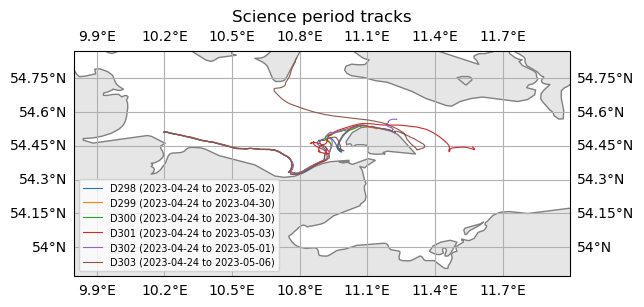

In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

land = cfeature.NaturalEarthFeature("physical", "land", "10m",
                                     facecolor="0.9", edgecolor="0.5")
ax.add_feature(land)
ax.set_extent([9.8, 12.0, 54.1, 55.1])
ax.gridlines(draw_labels=True)

for d_num, grp in df.groupby("D_number"):
    ax.plot(grp["Longitude"], grp["Latitude"], linewidth=0.8,
            label=f"D{d_num} ({grp.date_UTC.min().date()} to {grp.date_UTC.max().date()})")

ax.legend(fontsize=7)
ax.set_title("Science period tracks")
plt.show()

## Load CMEMS data

Open physics and wave datasets lazily via arco-geo-series. We only
select the time range covering the drifter period and let `interp()`
pull individual points on demand.

In [5]:
TIME = slice(TIME_START, TIME_END)

# Bounding box from drifter positions, with some padding
lon_min, lon_max = df_obs["Longitude"].min() - 0.2, df_obs["Longitude"].max() + 0.2
lat_min, lat_max = df_obs["Latitude"].min() - 0.2, df_obs["Latitude"].max() + 0.2
LON = slice(lon_min, lon_max)
LAT = slice(lat_min, lat_max)

ds_phy = cm.open_dataset(
    dataset_id="cmems_mod_bal_phy_anfc_PT1H-i",
    service="arco-geo-series",
)[["uo", "vo"]].sel(
    longitude=LON, latitude=LAT, time=TIME, depth=slice(0, 5),
)

WAVE_VARS = [
    "VHM0_WW", "VTM01_WW", "VMDR_WW",
    "VHM0_SW1", "VTM01_SW1", "VMDR_SW1",
    "VHM0_SW2", "VTM01_SW2", "VMDR_SW2",
]

ds_wav = cm.open_dataset(
    dataset_id="cmems_mod_bal_wav_anfc_PT1H-i",
    service="arco-geo-series",
).sel(longitude=LON, latitude=LAT, time=TIME)[WAVE_VARS]

print(f"Physics: {ds_phy.dims}")
print(f"Waves:   {ds_wav.dims}")

INFO - 2026-03-26T16:39:28Z - Selected dataset version: "202411"


INFO - 2026-03-26T16:39:28Z - Selected dataset part: "default"


INFO - 2026-03-26T16:39:30Z - Selected dataset version: "202311"


INFO - 2026-03-26T16:39:30Z - Selected dataset part: "default"


Physics: FrozenMappingWarningOnValuesAccess({'time': 408, 'depth': 5, 'latitude': 55, 'longitude': 64})
Waves:   FrozenMappingWarningOnValuesAccess({'time': 408, 'latitude': 55, 'longitude': 64})


## Sample Eulerian currents along tracks

For each drifter fix, interpolate uo and vo at the drifter position and
time, at the shallowest CMEMS depth level (~0.5 m, proxy for surface)
and at the nearest level to the drogue depth (~3.6 m CMEMS level for a
3 m drogue). Uses `xr.Dataset.interp()` which works lazily on
arco-geo-series.

In [6]:
# Build xarray coordinates for interpolation
times = xr.DataArray(pd.DatetimeIndex(df_obs["date_UTC"].values), dims="obs")
lons = xr.DataArray(df_obs["Longitude"].values, dims="obs")
lats = xr.DataArray(df_obs["Latitude"].values, dims="obs")

# Depth levels: surface (~0.5 m) and drogue (~3.6 m)
depth_levels = ds_phy.depth.values
z_surf = depth_levels[0]   # ~0.5 m
z_3m = depth_levels[3]     # ~3.6 m

euler_sampled = ds_phy.interp(
    longitude=lons, latitude=lats, time=times, method="linear",
).compute()

df_obs["uo_surf"] = euler_sampled["uo"].sel(depth=z_surf).values
df_obs["vo_surf"] = euler_sampled["vo"].sel(depth=z_surf).values
df_obs["uo_3m"] = euler_sampled["uo"].sel(depth=z_3m).values
df_obs["vo_3m"] = euler_sampled["vo"].sel(depth=z_3m).values

print(f"Eulerian sampled: {df_obs[['uo_surf','vo_surf']].notna().all(axis=1).sum()} valid of {len(df_obs)}")

Eulerian sampled: 949 valid of 1143


## Compute Stokes drift along tracks

For each fix, sample the wave partition parameters and compute Stokes
drift at surface (z=0) and at drogue depth (z=3 m) using the deep-water
monochromatic approximation per partition, same as notebook 06.

In [7]:
g = 9.81

PARTITIONS = [
    ("VHM0_WW", "VTM01_WW", "VMDR_WW"),
    ("VHM0_SW1", "VTM01_SW1", "VMDR_SW1"),
    ("VHM0_SW2", "VTM01_SW2", "VMDR_SW2"),
]

wav_sampled = ds_wav.interp(
    longitude=lons, latitude=lats, time=times, method="linear",
).compute()

for label, z in [("0m", 0.0), ("3m", float(z_3m))]:
    u_st = np.zeros(len(df_obs))
    v_st = np.zeros(len(df_obs))

    for hs_var, t_var, dir_var in PARTITIONS:
        hs = wav_sampled[hs_var].values
        T = wav_sampled[t_var].values
        dir_from = wav_sampled[dir_var].values

        valid = (hs > 0.01) & np.isfinite(T) & (T > 0.1)
        A = np.where(valid, hs / 2, 0.0)
        sigma = np.where(valid, 2 * np.pi / np.where(valid, T, 1.0), 0.0)
        k = sigma**2 / g
        theta = np.deg2rad(270.0 - np.where(valid, dir_from, 0.0))
        decay = np.exp(-2 * k * z)
        mag = A**2 * sigma * k * decay

        u_st += mag * np.cos(theta)
        v_st += mag * np.sin(theta)

    df_obs[f"u_stokes_{label}"] = u_st
    df_obs[f"v_stokes_{label}"] = v_st

print(f"Stokes at surface: mean speed {np.sqrt(df_obs['u_stokes_0m']**2 + df_obs['v_stokes_0m']**2).mean():.4f} m/s")
print(f"Stokes at 3m:      mean speed {np.sqrt(df_obs['u_stokes_3m']**2 + df_obs['v_stokes_3m']**2).mean():.4f} m/s")

Stokes at surface: mean speed 0.1095 m/s
Stokes at 3m:      mean speed 0.0060 m/s


## Compute predictions

Three prediction types at each drifter fix:
- **Surface**: effective current at the surface (Eulerian at ~0.5 m + Stokes at z=0)
- **Drogue depth**: effective current at drogue depth (Eulerian at ~3.6 m + Stokes at z=3 m)
- **Alpha-weighted**: `(1-alpha) * U_eff(drogue) + alpha * U_eff(surface)` where
  `alpha = sqrt(k_b) / (sqrt(k_b) + sqrt(k_d))` from the steady-state drag balance

In [8]:
# Effective currents at each depth
df_obs["u_eff_surf"] = df_obs["uo_surf"] + df_obs["u_stokes_0m"]
df_obs["v_eff_surf"] = df_obs["vo_surf"] + df_obs["v_stokes_0m"]
df_obs["u_eff_3m"] = df_obs["uo_3m"] + df_obs["u_stokes_3m"]
df_obs["v_eff_3m"] = df_obs["vo_3m"] + df_obs["v_stokes_3m"]

# Alpha weighting
alpha = np.sqrt(K_B) / (np.sqrt(K_B) + np.sqrt(K_D))
print(f"alpha = {alpha:.3f}")

df_obs["u_pred_alpha"] = (1 - alpha) * df_obs["u_eff_3m"] + alpha * df_obs["u_eff_surf"]
df_obs["v_pred_alpha"] = (1 - alpha) * df_obs["v_eff_3m"] + alpha * df_obs["v_eff_surf"]

# Speeds
df_obs["speed_obs"] = np.sqrt(df_obs["u_obs"]**2 + df_obs["v_obs"]**2)
df_obs["speed_surf"] = np.sqrt(df_obs["u_eff_surf"]**2 + df_obs["v_eff_surf"]**2)
df_obs["speed_3m"] = np.sqrt(df_obs["u_eff_3m"]**2 + df_obs["v_eff_3m"]**2)
df_obs["speed_alpha"] = np.sqrt(df_obs["u_pred_alpha"]**2 + df_obs["v_pred_alpha"]**2)

# Drop rows where model data is missing (near coast)
df_valid = df_obs.dropna(subset=["uo_surf", "uo_3m"]).copy()
print(f"{len(df_valid)} valid fixes out of {len(df_obs)} ({len(df_obs) - len(df_valid)} dropped near coast)")

alpha = 0.218
949 valid fixes out of 1143 (194 dropped near coast)


## Velocity comparison time series

Observed vs predicted velocity (u and v components) for one example
drifter, showing all three prediction types.

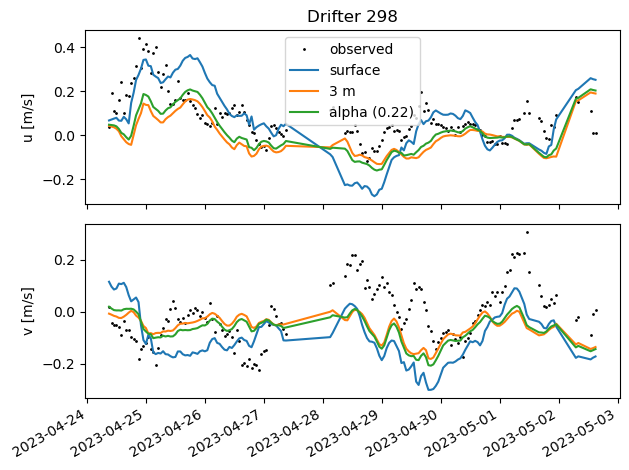

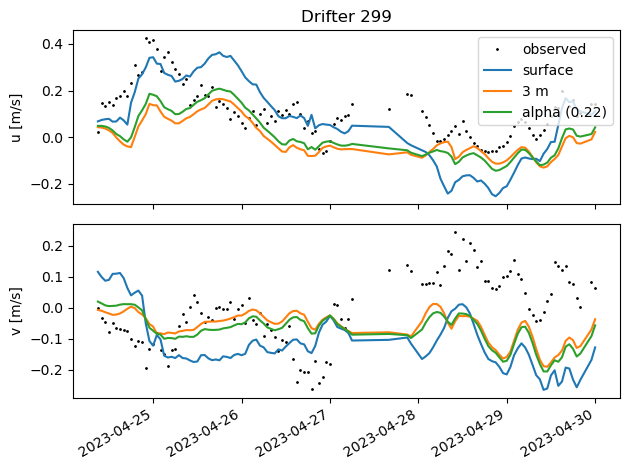

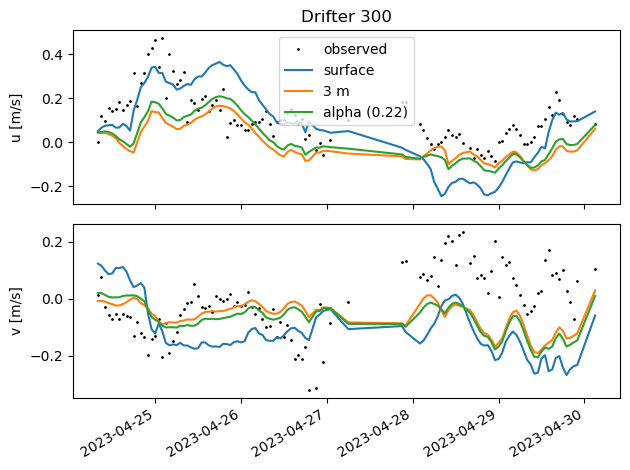

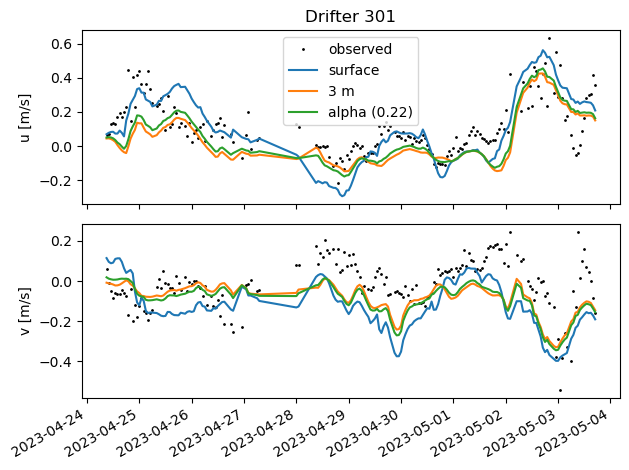

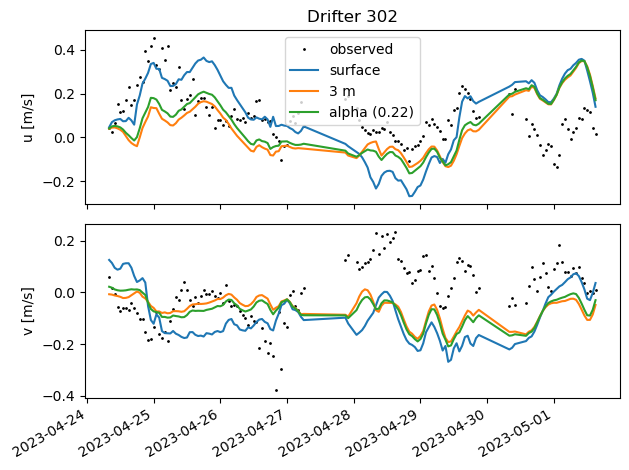

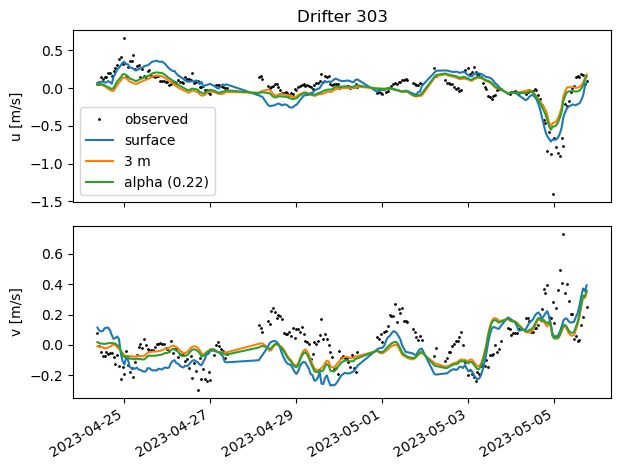

In [9]:
drifter_ids = sorted(df_valid["D_number"].unique())

for d_num in drifter_ids:
    sel = df_valid[df_valid["D_number"] == d_num]
    t = sel["date_UTC"]

    fig, (ax_u, ax_v) = plt.subplots(2, 1, sharex=True)

    ax_u.plot(t, sel["u_obs"], "k.", markersize=2, label="observed")
    ax_u.plot(t, sel["u_eff_surf"], label="surface")
    ax_u.plot(t, sel["u_eff_3m"], label="3 m")
    ax_u.plot(t, sel["u_pred_alpha"], label=f"alpha ({alpha:.2f})")
    ax_u.set_ylabel("u [m/s]")
    ax_u.legend()
    ax_u.set_title(f"Drifter {d_num}")

    ax_v.plot(t, sel["v_obs"], "k.", markersize=2, label="observed")
    ax_v.plot(t, sel["v_eff_surf"], label="surface")
    ax_v.plot(t, sel["v_eff_3m"], label="3 m")
    ax_v.plot(t, sel["v_pred_alpha"], label=f"alpha ({alpha:.2f})")
    ax_v.set_ylabel("v [m/s]")

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

## Scatter: observed vs predicted speed

All six drifters together, one panel per prediction type.

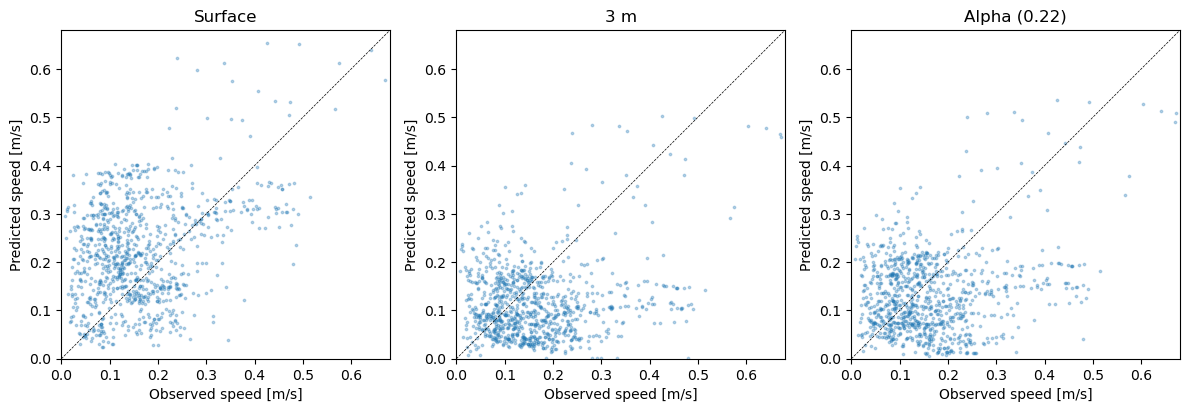

In [10]:
pred_types = [
    ("speed_surf", "Surface"),
    ("speed_3m", "3 m"),
    ("speed_alpha", f"Alpha ({alpha:.2f})"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
vmax = max(df_valid["speed_obs"].quantile(0.99), 0.5)

for ax, (col, label) in zip(axes, pred_types):
    ax.scatter(df_valid["speed_obs"], df_valid[col], s=3, alpha=0.3)
    ax.plot([0, vmax], [0, vmax], "k--", linewidth=0.5)
    ax.set_xlim(0, vmax)
    ax.set_ylim(0, vmax)
    ax.set_xlabel("Observed speed [m/s]")
    ax.set_ylabel("Predicted speed [m/s]")
    ax.set_title(label)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Velocity RMSE and correlation

Per drifter and overall, for each prediction type. RMSE is computed on
the u and v components jointly (not on speed).

In [11]:
def velocity_rmse(df, u_pred, v_pred):
    """RMSE of vector velocity components."""
    du = df["u_obs"] - df[u_pred]
    dv = df["v_obs"] - df[v_pred]
    return np.sqrt((du**2 + dv**2).mean())

def velocity_corr(df, u_pred, v_pred):
    """Mean of u and v Pearson correlations."""
    r_u = df["u_obs"].corr(df[u_pred])
    r_v = df["v_obs"].corr(df[v_pred])
    return (r_u + r_v) / 2

pred_configs = [
    ("Surface", "u_eff_surf", "v_eff_surf"),
    ("3 m", "u_eff_3m", "v_eff_3m"),
    ("Alpha", "u_pred_alpha", "v_pred_alpha"),
]

rows = []
for drifter_id in sorted(df_valid["D_number"].unique()):
    d = df_valid[df_valid["D_number"] == drifter_id]
    for label, u_col, v_col in pred_configs:
        rows.append({
            "Drifter": drifter_id,
            "Prediction": label,
            "RMSE [m/s]": velocity_rmse(d, u_col, v_col),
            "Correlation": velocity_corr(d, u_col, v_col),
            "N": len(d),
        })

# Overall
for label, u_col, v_col in pred_configs:
    rows.append({
        "Drifter": "All",
        "Prediction": label,
        "RMSE [m/s]": velocity_rmse(df_valid, u_col, v_col),
        "Correlation": velocity_corr(df_valid, u_col, v_col),
        "N": len(df_valid),
    })

df_stats = pd.DataFrame(rows)
df_stats_pivot = df_stats.pivot_table(
    index="Drifter", columns="Prediction",
    values=["RMSE [m/s]", "Correlation"],
).round(3)
df_stats_pivot

Correlation                RMSE [m/s]               
Prediction         3 m  Alpha Surface        3 m  Alpha Surface
Drifter                                                        
298              0.324  0.402   0.489      0.177  0.169   0.193
299              0.175  0.219   0.291      0.203  0.197   0.226
300              0.183  0.232   0.305      0.205  0.199   0.229
301              0.551  0.586   0.616      0.196  0.189   0.211
302             -0.012  0.073   0.257      0.218  0.213   0.236
303              0.608  0.645   0.675      0.217  0.207   0.214
All              0.425  0.475   0.528      0.204  0.197   0.217

## RMSE by drifter

Bar chart comparing the three prediction types for each drifter.

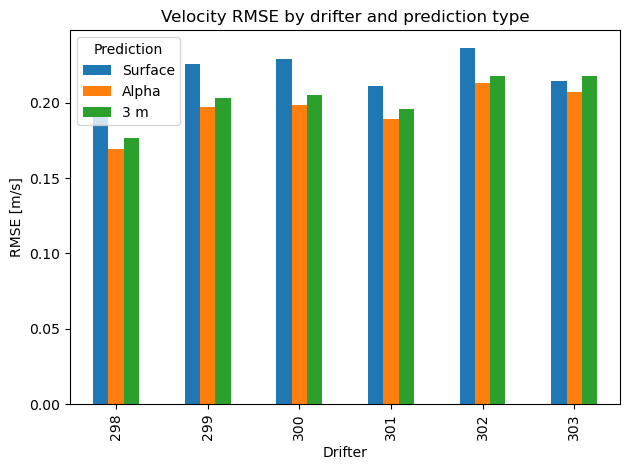

In [12]:
df_rmse = df_stats[df_stats["Drifter"] != "All"].pivot_table(
    index="Drifter", columns="Prediction", values="RMSE [m/s]",
)
df_rmse = df_rmse[["Surface", "Alpha", "3 m"]]

df_rmse.plot.bar()
plt.ylabel("RMSE [m/s]")
plt.title("Velocity RMSE by drifter and prediction type")
plt.legend(title="Prediction")
plt.tight_layout()
plt.show()

## Direction validation

Angular difference between observed and predicted drift direction at
each hourly fix. Direction is computed as `atan2(v, u)`. The angular
error is wrapped to [-180, 180] degrees.

In [ ]:
def angular_diff_deg(u_obs, v_obs, u_pred, v_pred):
    """Signed angular difference (obs - pred) in degrees, wrapped to [-180, 180]."""
    dir_obs = np.arctan2(v_obs, u_obs)
    dir_pred = np.arctan2(v_pred, u_pred)
    diff = dir_obs - dir_pred
    # Wrap to [-pi, pi]
    diff = (diff + np.pi) % (2 * np.pi) - np.pi
    return np.degrees(diff)

# Compute direction error for each prediction type
for label, u_col, v_col in pred_configs:
    col_name = f"dir_err_{label.lower().replace(' ', '_')}"
    df_valid[col_name] = angular_diff_deg(
        df_valid["u_obs"].values, df_valid["v_obs"].values,
        df_valid[u_col].values, df_valid[v_col].values,
    )

# Filter out near-zero speeds (direction undefined)
MIN_SPEED = 0.02  # m/s
df_dir = df_valid[df_valid["speed_obs"] > MIN_SPEED].copy()
print(f"{len(df_dir)} fixes with speed > {MIN_SPEED} m/s")

### Direction error histograms

Distribution of angular error for each prediction type. A narrow peak
around 0 means the predicted direction matches. Tails at +/-180
indicate reversed drift.

In [ ]:
fig, axes = plt.subplots(1, 3, sharey=True)

for ax, (label, u_col, v_col) in zip(axes, pred_configs):
    col = f"dir_err_{label.lower().replace(' ', '_')}"
    data = df_dir[col].dropna()
    ax.hist(data, bins=np.arange(-180, 181, 10), edgecolor="k", alpha=0.7)
    ax.axvline(0, color="r", ls="--", linewidth=0.5)
    ax.set_xlabel("Direction error [deg]")
    ax.set_title(label)
    mae = np.abs(data).mean()
    frac_90 = (np.abs(data) < 90).mean() * 100
    ax.text(0.05, 0.95, f"MAE={mae:.0f}°\n<90°: {frac_90:.0f}%",
            transform=ax.transAxes, va="top", fontsize=7)

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

### Direction error time series per drifter

In [ ]:
for d_num in drifter_ids:
    sel = df_dir[df_dir["D_number"] == d_num]
    t = sel["date_UTC"]

    fig, ax = plt.subplots()
    for label, _, _ in pred_configs:
        col = f"dir_err_{label.lower().replace(' ', '_')}"
        ax.plot(t, sel[col], ".", markersize=2, label=label, alpha=0.6)

    ax.axhline(0, color="k", linewidth=0.5)
    ax.axhline(90, color="k", linewidth=0.3, ls=":")
    ax.axhline(-90, color="k", linewidth=0.3, ls=":")
    ax.set_ylim(-180, 180)
    ax.set_ylabel("Direction error [deg]")
    ax.set_title(f"D{d_num}")
    ax.legend(fontsize=7)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

### Direction error summary

Mean absolute error (MAE) and fraction of fixes with error < 90 degrees,
per drifter and prediction type.

In [ ]:
rows = []
for d_num in list(drifter_ids) + ["All"]:
    sel = df_dir if d_num == "All" else df_dir[df_dir["D_number"] == d_num]
    for label, _, _ in pred_configs:
        col = f"dir_err_{label.lower().replace(' ', '_')}"
        data = sel[col].dropna()
        rows.append({
            "Drifter": d_num,
            "Prediction": label,
            "MAE [deg]": np.abs(data).mean(),
            "< 90 deg [%]": (np.abs(data) < 90).mean() * 100,
            "N": len(data),
        })

df_dir_stats = pd.DataFrame(rows)
df_dir_stats.pivot_table(
    index="Drifter", columns="Prediction",
    values=["MAE [deg]", "< 90 deg [%]"],
).round(1)